# Merging Climate Datasets Exercise

Work through this notebook to practice harmonizing and merging two climate datasets that differ in temporal cadence and spatial resolution.

You will: 
- Load two public NOAA datasets directly from the cloud
- Subset to the continental US (use 230°E–300°E in longitude since the data span 0–360°)
- Use `xr.resample` to aggregate time and `xr.interp` to match grids
- Combine the variables with `xr.merge` for joint analysis

Refer back to the answer key after attempting each step.


## 1. Setup


In [11]:
import matplotlib.pyplot as plt
import xarray as xr

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ImportError:
    ccrs = None
    cfeature = None

TEMP_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/surface/air.sig995.2020.nc"
PRECIP_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/cpc_global_precip/precip.2020.nc"

LAT_RANGE = (50, 20)  # degrees North
LON_RANGE_360 = (230, 300)  # degrees East (equivalent to -130° to -60°)
LON_RANGE_180 = (-130, -60)  # convenience if a dataset uses -180° to 180°

TIME_RANGE = slice("2020-06-01", "2020-06-30")


## 2. Load the datasets

Open both remote datasets with `xr.open_dataset`, passing a reasonable chunk size for the time dimension. Assign the resulting objects to `air` and `precip`.


In [12]:
# TODO: load the air temperature and precipitation datasets.
# Example: air = xr.open_dataset(..., chunks={"time": 8})
air = xr.open_dataset(TEMP_URL, chunks={"time" : 8})
precip = xr.open_dataset(PRECIP_URL, chunks={"time" : 8})
# raise NotImplementedError("Assign datasets to `air` and `precip`.")


In [13]:
precip

<xarray.Dataset> Size: 379MB
Dimensions:  (time: 366, lat: 360, lon: 720)
Coordinates:
  * lat      (lat) float32 1kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * lon      (lon) float32 3kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * time     (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
Data variables:
    precip   (time, lat, lon) float32 379MB dask.array<chunksize=(8, 360, 720), meta=np.ndarray>
Attributes:
    _NCProperties:                   version=1|netcdflibversion=4.4.1.1|hdf5l...
    Conventions:                     CF-1.0
    version:                         V1.0
    title:                           CPC GLOBAL PRCP V1.0 RT
    dataset_title:                   CPC GLOBAL PRCP V1.0
    Source:                          ftp://ftp.cpc.ncep.noaa.gov/precip/CPC_U...
    References:                      https://www.psl.noaa.gov/data/gridded/da...
    history:                         Updated 2021-01-02 23:31:03
    DODS_EXTRA.Unlimited_Dimension:  time

## 3. Subset to the continental United States and June 2020

Select the bounding box provided above and limit the time range to June 2020 for both datasets. Store the results in `air_us` and `precip_us`.
Remember that longitude runs from 0° to 360°, so select 230°E–300°E. Check whether each coordinate is ascending or descending before building the slice.


In [17]:
# TODO: subset both datasets using `sel`, handling coordinate ordering as needed.
air_us = air.sel(time= TIME_RANGE, lon= slice(*LON_RANGE_360), lat= slice(*LAT_RANGE))
precip_us = precip.sel(time= TIME_RANGE, lon= slice(*LON_RANGE_360), lat= slice(*LAT_RANGE))
# raise NotImplementedError("Create `air_us` and `precip_us`.")
air_us


<xarray.Dataset> Size: 182kB
Dimensions:  (time: 120, lat: 13, lon: 29)
Coordinates:
  * lat      (lat) float32 52B 50.0 47.5 45.0 42.5 40.0 ... 27.5 25.0 22.5 20.0
  * lon      (lon) float32 116B 230.0 232.5 235.0 237.5 ... 295.0 297.5 300.0
  * time     (time) datetime64[ns] 960B 2020-06-01 ... 2020-06-30T18:00:00
Data variables:
    air      (time, lat, lon) float32 181kB dask.array<chunksize=(8, 13, 29), meta=np.ndarray>
Attributes:
    Conventions:                     COARDS
    title:                           4x daily NMC reanalysis (2014)
    history:                         created 2017/12 by Hoop (netCDF2.3)
    description:                     Data is from NMC initialized reanalysis\...
    platform:                        Model
    dataset_title:                   NCEP-NCAR Reanalysis 1
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    References:                      http://www.psl.noaa.gov/data/gridded/dat...
    DODS_EXTRA.Unlimited_Dimension:  time

## 4. Align temporal cadence

Aggregate the six-hourly air temperatures to daily means with `xr.resample`. Name the resulting DataArray `air_daily`.


In [29]:
# TODO: use xr.resample to create daily means.
# raise NotImplementedError("Create `air_daily`.")
air_daily = air_us.resample(time="1D").mean()


In [30]:
air_daily

<xarray.Dataset> Size: 46kB
Dimensions:  (time: 30, lat: 13, lon: 29)
Coordinates:
  * lat      (lat) float32 52B 50.0 47.5 45.0 42.5 40.0 ... 27.5 25.0 22.5 20.0
  * lon      (lon) float32 116B 230.0 232.5 235.0 237.5 ... 295.0 297.5 300.0
  * time     (time) datetime64[ns] 240B 2020-06-01 2020-06-02 ... 2020-06-30
Data variables:
    air      (time, lat, lon) float32 45kB dask.array<chunksize=(1, 13, 29), meta=np.ndarray>
Attributes:
    Conventions:                     COARDS
    title:                           4x daily NMC reanalysis (2014)
    history:                         created 2017/12 by Hoop (netCDF2.3)
    description:                     Data is from NMC initialized reanalysis\...
    platform:                        Model
    dataset_title:                   NCEP-NCAR Reanalysis 1
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    References:                      http://www.psl.noaa.gov/data/gridded/dat...
    DODS_EXTRA.Unlimited_Dimension:  time

## 5. Interpolate to the precipitation grid

Use `xr.interp` to interpolate the daily air temperatures onto the precipitation grid (`precip_us.lat` and `precip_us.lon`). Store the interpolated result in `air_interp`.


In [31]:
# TODO: interpolate the resampled temperature field onto the precipitation grid.
# raise NotImplementedError("Create `air_interp`.")
air_interp = air_daily.interp(lat=precip_us.lat, lon=precip_us.lon, method="nearest")


## 6. Merge the datasets

Convert the aligned arrays into datasets with clear variable names and merge them with `xr.merge`. Save the output as `merged`.


In [32]:
# TODO: build datasets and merge them into one object named `merged`.
# raise NotImplementedError("Create `merged`.")
merged = xr.Dataset({"air_temperature": air_interp["air"], "daily_precip": precip_us["precip"]})
merged


<xarray.Dataset> Size: 2MB
Dimensions:          (time: 30, lat: 60, lon: 140)
Coordinates:
  * time             (time) datetime64[ns] 240B 2020-06-01 ... 2020-06-30
  * lat              (lat) float32 240B 49.75 49.25 48.75 ... 21.25 20.75 20.25
  * lon              (lon) float32 560B 230.2 230.8 231.2 ... 298.8 299.2 299.8
Data variables:
    air_temperature  (time, lat, lon) float32 1MB dask.array<chunksize=(1, 60, 140), meta=np.ndarray>
    daily_precip     (time, lat, lon) float32 1MB dask.array<chunksize=(8, 60, 140), meta=np.ndarray>

## 7. Inspect your result

Once your pipeline runs without `NotImplementedError`, evaluate the following cell to sanity-check the merged dataset.


In [33]:
# The assertions below should pass once you have completed the exercise.
assert set(merged.data_vars) == {"air_temperature", "daily_precip"}
assert merged.air_temperature.dims == merged.daily_precip.dims
print(merged)


<xarray.Dataset> Size: 2MB
Dimensions:          (time: 30, lat: 60, lon: 140)
Coordinates:
  * time             (time) datetime64[ns] 240B 2020-06-01 ... 2020-06-30
  * lat              (lat) float32 240B 49.75 49.25 48.75 ... 21.25 20.75 20.25
  * lon              (lon) float32 560B 230.2 230.8 231.2 ... 298.8 299.2 299.8
Data variables:
    air_temperature  (time, lat, lon) float32 1MB dask.array<chunksize=(1, 60, 140), meta=np.ndarray>
    daily_precip     (time, lat, lon) float32 1MB dask.array<chunksize=(8, 60, 140), meta=np.ndarray>


## 8. Check In

- Render both variables at the first timestep on a `cartopy` map to verify alignment visually (PlateCarree works well).
- Build a scatter plot comparing colocated temperature and precipitation values across the merged domain.
- Save the merged output with `to_netcdf` for future analysis.


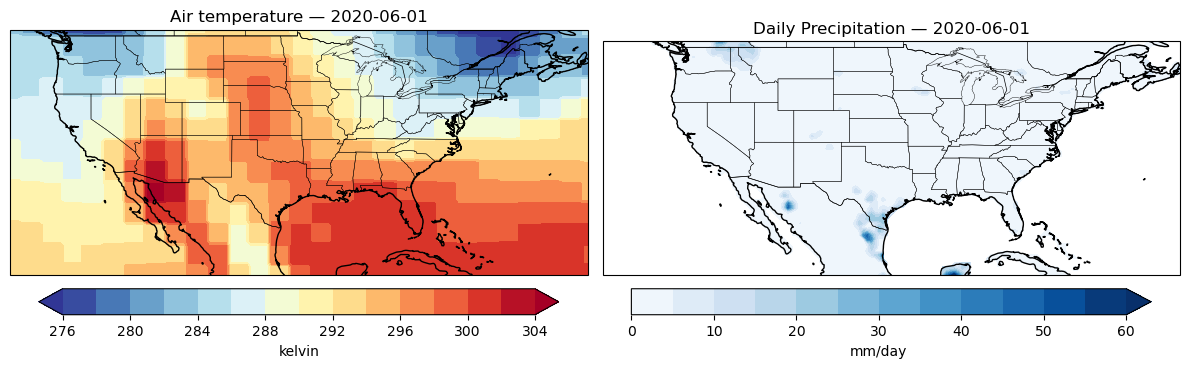

In [69]:
# SEPARATED PLOT
fig = plt.figure(figsize=(12, 5))

# Air temperature
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.set_title(f"Air temperature — {merged.time.dt.strftime('%Y-%m-%d').isel(time=0).item()}")
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
ax1.add_feature(cfeature.STATES, linewidth=0.3)
cf1 = ax1.contourf(merged.lon, merged.lat, merged["air_temperature"].isel(time=0), 15,
                   extend= "both", cmap= "RdYlBu_r", transform=ccrs.PlateCarree())
cb1 = plt.colorbar(cf1, ax=ax1, orientation="horizontal", pad=0.03, shrink=0.9)
cb1.set_label("kelvin")

# Daily precipitation 
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
ax2.set_title(f"Daily Precipitation — {merged.time.dt.strftime('%Y-%m-%d').isel(time=0).item()}")
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
ax2.add_feature(cfeature.STATES, linewidth=0.3)
cf2 = ax2.contourf(merged.lon, merged.lat, merged["daily_precip"].isel(time=0), 15,
                   extend= "max", cmap= "Blues", transform=ccrs.PlateCarree())
cb2 = plt.colorbar(cf2, ax=ax2, orientation="horizontal", pad=0.03, shrink=0.9)
cb2.set_label("mm/day")

plt.savefig("/data/keeling/a/deffip2/ATMS_523/HW_3_Module_3/ATMS-523-Module-3-CheckIn-Deffip2/SeparatedPlot.png", 
            dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


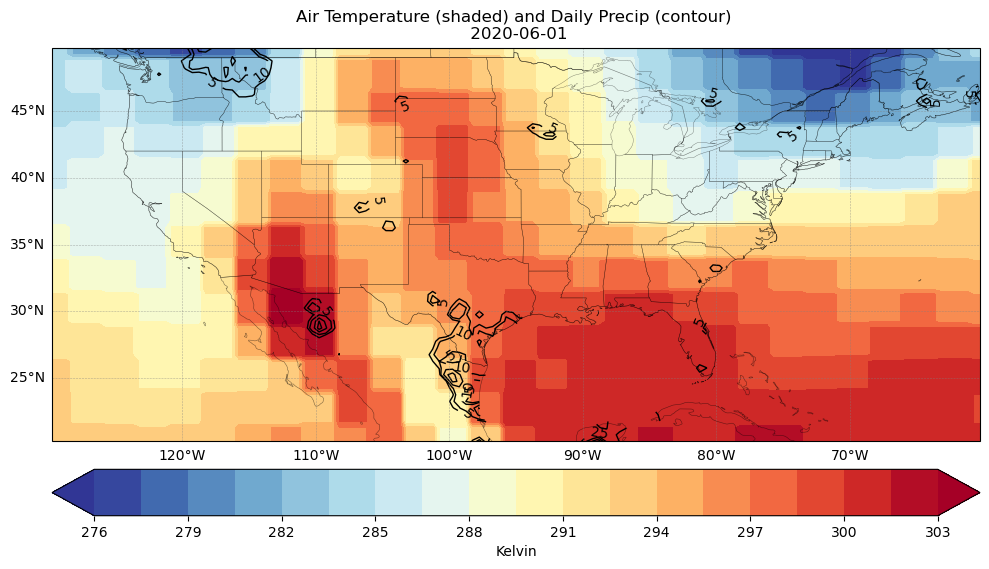

In [70]:
# COMBINED PLOT

fig = plt.figure(figsize=(10, 6))
ax  = plt.axes(projection=ccrs.PlateCarree())

ax.set_title(f"Air Temperature (shaded) and Daily Precip (contour) \n {merged.time.dt.strftime('%Y-%m-%d').isel(time=0).item()}")
ax.coastlines(linewidth=0.4, alpha=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)

cf = ax.contourf(
    merged.lon,
    merged.lat,
    merged["air_temperature"].isel(time=0),
    levels=20, cmap="RdYlBu_r", extend="both",
    transform=ccrs.PlateCarree()
)
plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05,
             label="Kelvin")

cs = ax.contour(
    merged.lon,
    merged.lat,
    merged["daily_precip"].isel(time=0),
    levels=[5, 10, 25, 40, 50, 60],
    colors="k", linewidths=1,
    transform=ccrs.PlateCarree()
)
ax.clabel(cs, fmt="%g", fontsize=10)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.6, linestyle="--")
gl.top_labels = False; gl.right_labels = False

plt.savefig("/data/keeling/a/deffip2/ATMS_523/HW_3_Module_3/ATMS-523-Module-3-CheckIn-Deffip2/CombinedPlot.png",
            dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

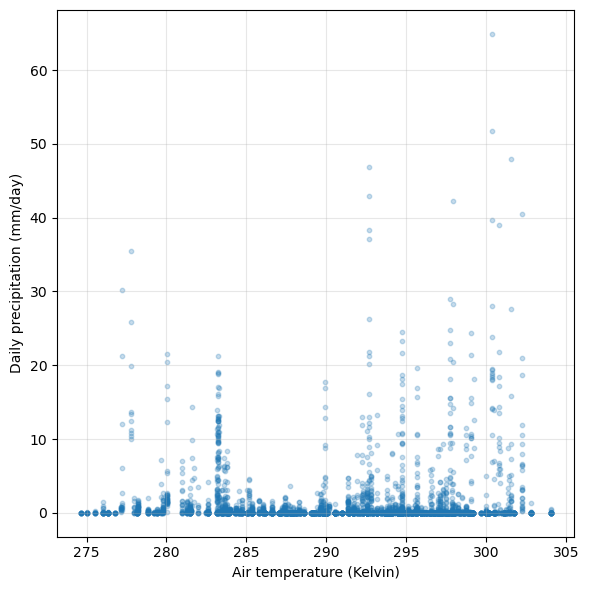

In [71]:
T = merged["air_temperature"].isel(time=0).values
P = merged["daily_precip"].isel(time=0).values

plt.figure(figsize=(6,6))
plt.scatter(T, P, s=10, alpha=0.25)
plt.xlabel("Air temperature (Kelvin)")
plt.ylabel("Daily precipitation (mm/day)")
plt.grid(alpha=0.3)

plt.savefig("/data/keeling/a/deffip2/ATMS_523/HW_3_Module_3/ATMS-523-Module-3-CheckIn-Deffip2/ScatterPlot.png",
            dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [ ]:
# Save file to the selected path in netcdf file extension

merged.to_netcdf("/data/keeling/a/deffip2/ATMS_523/HW_3_Module_3/ATMS-523-Module-3-CheckIn-Deffip2/merged_US_2020.nc")